<a href="https://colab.research.google.com/github/AbishekPokhrel/AbishekPokhrel/blob/main/colab-notebooks/Week2_Tokenization_and_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 Live Demo: Tokenization and Embeddings

In this Colab notebook, you will see how a language model turns text into tokens and numerical IDs, then explore the model's pre-trained embedding space.
## Learning goals

By the end of this demo, you should be able to: (1) explain why models use tokens and token IDs; (2) compare GPT-2 and BERT tokenization; (3) describe an embedding as a vector representation; and (4) use PCA, t-SNE, and nearest neighbors to inspect embeddings.

## Section 1 — Python review

This short review uses a Python variable, a list, and a function. Notice that a function can accept an input and return a result.

In [13]:
course_topic = 'Tokenization and Embeddings'
example_words = ['language', 'model', 'token']

def describe_words(words):
    return f'We will inspect {len(words)} example words: {words}'

print(course_topic)
print(describe_words(example_words))

Tokenization and Embeddings
We will inspect 3 example words: ['language', 'model', 'token']


## Section 2 — Install and import libraries

Run this cell once. `transformers` provides model and tokenizer tools; `tokenizers` supports fast tokenization; `datasets` is commonly used to work with NLP datasets. The visualization libraries will be used later.

In [14]:
!pip -q install transformers tokenizers datasets scikit-learn matplotlib

import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

## Section 3 — Load a GPT tokenizer

A **tokenizer** divides text into units a model recognizes. Those units may be full words, word pieces, punctuation, or characters. GPT-2 uses a byte-pair encoding tokenizer.

In [15]:
gpt_tokenizer = AutoTokenizer.from_pretrained('gpt2')
print('GPT tokenizer loaded.')

GPT tokenizer loaded.


## Section 4 — Tokenize text

Run the cell and inspect the result. In GPT-2 output, `Ġ` commonly marks a token that begins after a space. It is part of how GPT-2 records word boundaries.

In [16]:
text = 'LLMs, AI, and machine learning are taking the world to the next level.'
# text = '人工智能很可怕吗'
# text = '❓️'
# text = 'Tokenization'
tokens = gpt_tokenizer.tokenize(text)

print('Original text:', text)
print('GPT-2 tokens:', tokens)
print('Number of tokens:', len(tokens))

Original text: LLMs, AI, and machine learning are taking the world to the next level.
GPT-2 tokens: ['LL', 'Ms', ',', 'ĠAI', ',', 'Ġand', 'Ġmachine', 'Ġlearning', 'Ġare', 'Ġtaking', 'Ġthe', 'Ġworld', 'Ġto', 'Ġthe', 'Ġnext', 'Ġlevel', '.']
Number of tokens: 17


### Try it

Replace `text` with your name, a technical term, an emoji, or a sentence in another language. Which examples show one world becomes more than one token?

## Section 5 — Token IDs

A model cannot directly compute with strings. The tokenizer maps each token to an integer **ID** from its vocabulary. IDs are labels, not numerical meanings: token ID 100 is not inherently more similar to ID 101 than to ID 5000.

In [17]:
ids = gpt_tokenizer.encode(text, add_special_tokens=False)
print('Token IDs:', ids)
print('ID-to-token check:', gpt_tokenizer.convert_ids_to_tokens(ids))
print('Decoded text:', gpt_tokenizer.decode(ids))

Token IDs: [3069, 10128, 11, 9552, 11, 290, 4572, 4673, 389, 2263, 262, 995, 284, 262, 1306, 1241, 13]
ID-to-token check: ['LL', 'Ms', ',', 'ĠAI', ',', 'Ġand', 'Ġmachine', 'Ġlearning', 'Ġare', 'Ġtaking', 'Ġthe', 'Ġworld', 'Ġto', 'Ġthe', 'Ġnext', 'Ġlevel', '.']
Decoded text: LLMs, AI, and machine learning are taking the world to the next level.


## Section 6 — Compare GPT-2 and BERT tokenizers

GPT-2 and BERT were trained with different tokenization schemes and training objectives, so they may divide the same text differently. BERT uses special tokens such as `[CLS]` and `[SEP]` by default. To compare only the text pieces, this cell does not add special tokens.


In [18]:
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
examples = [
    'Large Language Models are changing AI.',
    'Tokenization affects what a model can represent.',
    'Wearable-sensor data can support injury prevention.'
]

for sentence in examples:
    print(f'\nText: {sentence}')
    print('GPT-2:', gpt_tokenizer.tokenize(sentence))
    print('BERT :', bert_tokenizer.tokenize(sentence))


Text: Large Language Models are changing AI.
GPT-2: ['Large', 'ĠLanguage', 'ĠModels', 'Ġare', 'Ġchanging', 'ĠAI', '.']
BERT : ['large', 'language', 'models', 'are', 'changing', 'ai', '.']

Text: Tokenization affects what a model can represent.
GPT-2: ['Token', 'ization', 'Ġaffects', 'Ġwhat', 'Ġa', 'Ġmodel', 'Ġcan', 'Ġrepresent', '.']
BERT : ['token', '##ization', 'affects', 'what', 'a', 'model', 'can', 'represent', '.']

Text: Wearable-sensor data can support injury prevention.
GPT-2: ['W', 'earable', '-', 's', 'ensor', 'Ġdata', 'Ġcan', 'Ġsupport', 'Ġinjury', 'Ġprevention', '.']
BERT : ['wear', '##able', '-', 'sensor', 'data', 'can', 'support', 'injury', 'prevention', '.']


**Observe:** Which tokenizer splits long or uncommon words more? How does each represent punctuation, capitalization, and hyphenated words?
**Notice** The ## symbols before a token mean that the token is a continuing subword and should attach directly to the previous token without a space. This is used by subword tokenization algorithms like WordPiece (famous for powering models like BERT) to break down rare or unknown words into smaller, recognizable pieces.

## Section 7 — Visualize pre-trained embeddings

An **embedding** is a learned vector for a token. GPT-2 has already learned an embedding matrix during pre-training. Each vector has 768 dimensions, so we will use PCA and t-SNE to display an approximate two-dimensional view. Points that appear near each other may have similar learned relationships, but a 2-D plot cannot capture every relationship in the original 768-D space.

In [19]:
gpt_model = AutoModel.from_pretrained('gpt2')
embedding_matrix = gpt_model.get_input_embeddings().weight.detach().cpu().numpy()
print('Embedding matrix shape:', embedding_matrix.shape)
print('Each row is one token embedding; each column is one embedding dimension.')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Embedding matrix shape: (50257, 768)
Each row is one token embedding; each column is one embedding dimension.


In [20]:
# Use words that GPT-2 represents with a single token after a space.
words = ['heart', 'brain', 'blood', 'bone', 'muscle',
         'run', 'sleep', 'eat', 'breathe',
         'happy', 'tired', 'sick', 'healthy']
selected_ids = []
selected_labels = []
for word in words:
    ids_for_word = gpt_tokenizer.encode(' ' + word, add_special_tokens=False)
    if len(ids_for_word) == 1:
        selected_ids.append(ids_for_word[0])
        selected_labels.append(word)
    else:
        print(f'Skipped {word!r}: it uses {len(ids_for_word)} tokens.')

vectors = embedding_matrix[selected_ids]
print('Words plotted:', selected_labels)
print('Vector array shape:', vectors.shape)

Words plotted: ['heart', 'brain', 'blood', 'bone', 'muscle', 'run', 'sleep', 'eat', 'breathe', 'happy', 'tired', 'sick', 'healthy']
Vector array shape: (13, 768)


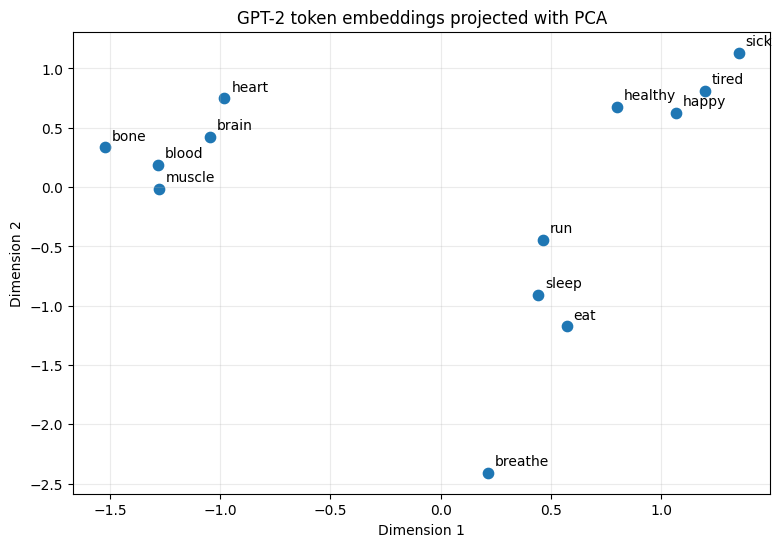

In [21]:
def plot_2d(points, labels, title):
    plt.figure(figsize=(9, 6))
    plt.scatter(points[:, 0], points[:, 1], s=55)
    for x, y, label in zip(points[:, 0], points[:, 1], labels):
        plt.annotate(label, (x, y), xytext=(5, 5), textcoords='offset points')
    plt.title(title)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(alpha=0.25)
    plt.show()

pca_points = PCA(n_components=2, random_state=42).fit_transform(vectors)
plot_2d(pca_points, selected_labels, 'GPT-2 token embeddings projected with PCA')

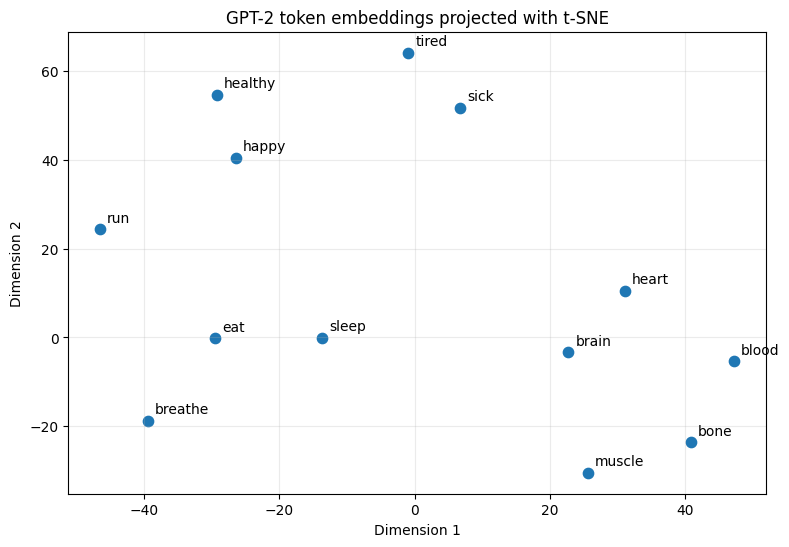

In [22]:
perplexity = min(5, len(selected_labels) - 1)
tsne_points = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca', learning_rate='auto').fit_transform(vectors)
plot_2d(tsne_points, selected_labels, 'GPT-2 token embeddings projected with t-SNE')

# Compare the two plots. t-SNE prioritizes local neighborhoods and can look different with other settings.

### Nearest neighbors

Cosine similarity measures how aligned two embedding vectors are. Values closer to 1 indicate more similar vector directions. This is a useful inspection tool, but it does not prove that two words have identical meanings.

In [23]:
def nearest_words(query, k=5):
    query_ids = gpt_tokenizer.encode(' ' + query, add_special_tokens=False)
    if len(query_ids) != 1:
        raise ValueError(f'Choose a word that becomes one GPT-2 token. {query!r} used {len(query_ids)} tokens.')
    query_vector = embedding_matrix[query_ids[0]].reshape(1, -1)
    scores = cosine_similarity(query_vector, vectors)[0]
    ranked = np.argsort(scores)[::-1]
    return [(selected_labels[i], round(float(scores[i]), 3)) for i in ranked if selected_labels[i] != query][:k]

for query in ['cat', 'doctor', 'run']:
    print(f'{query:>6} -> {nearest_words(query)}')

   cat -> [('sleep', 0.312), ('brain', 0.279), ('happy', 0.275), ('bone', 0.273), ('blood', 0.268)]
doctor -> [('sick', 0.388), ('blood', 0.333), ('brain', 0.332), ('breathe', 0.328), ('healthy', 0.327)]
   run -> [('eat', 0.281), ('happy', 0.263), ('breathe', 0.241), ('sleep', 0.228), ('tired', 0.22)]


## Section 8 — Discussion (15–20 minutes)

Choose one application: a course assistant, a creative writing assistant, a medical-information assistant, or a multilingual chatbot. Discuss and record brief answers:

1. Which tokenizer, GPT-2 or BERT, would you choose as a starting point, and why?
2. What trade-off matters most for your application: vocabulary coverage, handling of uncommon words, preserving capitalization, speed, or compatibility with a pre-trained model?
3. What did the nearest-neighbor results suggest about embeddings? What was surprising or misleading?
4. Why should we be cautious about interpreting distances in a 2-D PCA or t-SNE plot?

Be prepared to share one conclusion with the class.

Section 8 — Discussion

App I picked: medical-information assistant

1.Which tokenizer, GPT-2 or BERT, would you choose as a starting point, and why?

Answer:
I'd go with BERT for this one. Medical text has a ton of terms that aren't going to show up in a normal vocabulary — drug names, weird abbreviations, anatomy terms — and BERT's WordPiece thing breaks those into smaller chunks with the ## marker so it can still deal with a word it's never fully seen before. GPT-2 does something similar with BPE but it feels more built for generating text than understanding/classifying it, and for a medical assistant I care more about it correctly understanding input than writing long responses.

2.What trade-off matters most for your application: vocabulary coverage, handling of uncommon words, preserving capitalization, speed, or compatibility with a pre-trained model?

Answer:
Probably handling of uncommon words over anything else. In medicine basically every "rare" word is actually important — it's a diagnosis, a med name, a lab value — so the tokenizer can't just butcher it. Vocab coverage matters too but no tokenizer is going to have every medical term memorized anyway, so what matters more is how well it breaks down words it doesn't fully know.



3.What did the nearest-neighbor results suggest about embeddings? What was surprising or misleading?

Answer:
Honestly, the results were a little different from what I expected. The embeddings still showed that words can end up near other words with related contexts. For example, doctor was closest to sick, blood, brain, breathe, and healthy, which makes sense because those words are all connected to health and medicine. That suggests the embeddings learned some meaningful relationships during pretraining.

What was surprising was that cat ended up closest to sleep, brain, and happy instead of other animal-related words. But after changing the word list, there were no animal words left in the comparison pool, so the model had to choose the closest matches from the available options. This showed that nearest-neighbor results depend not only on the query word itself but also on which words are available for comparison. It was a good reminder that cosine similarity measures how similar vectors are, not whether humans would consider two words closely related in meaning.

4.Why should we be cautious about interpreting distances in a 2-D PCA or t-SNE plot?

Answer:
Because we're squishing a 768-dim vector down into 2 dimensions, so we're losing most of the info. With PCA specifically, two words could look far apart on the plot but actually be close in the real embedding space — the 2-D distance isn't the real distance. t-SNE is worse in a different way — it's built to keep local neighborhoods looking right, not the overall distances between clusters, so you can't really trust how far apart two clusters are or how big they look. Basically just use these plots to see if things vaguely group together, not to measure anything off them.




## Exit check

Before leaving, make sure you can explain: **text → tokens → token IDs → embedding vectors**. Change one input sentence and one word list, rerun the comparison and visualization, and write one observation in a Markdown cell.


Exit check

Basically: text gets broken into tokens by the tokenizer (BPE for GPT-2, WordPiece for BERT), each token gets mapped to some integer ID from the vocab (the ID itself doesn't mean anything, it's just a lookup number), and then the model uses that ID to grab a row out of the embedding matrix — that row is a vector (768 numbers for GPT-2) that actually represents the token in a way the model can compute with. Words that mean similar things end up with vectors that point in similar directions after training, which is basically why the nearest-neighbor and PCA/t-SNE stuff above worked at all.

Observation:

I swapped the word list to heart, brain, blood, bone, muscle, run, sleep, eat, breathe, happy, tired, sick, healthy. Since nearest_words still queries cat, doctor, and run but only compares against whatever's in the new list, the results changed a lot — cat is no longer near dog (since dog isn't in the pool anymore), it's now closest to sleep, brain, and happy, all around 0.27–0.31, way lower than the 0.55 score cat-dog got before. Same with doctor, which is now closest to sick, blood, brain, breathe, and healthy — which actually fits this word set better.

The main thing this showed me is that nearest-neighbor results depend just as much on what's in the candidate pool as they do on the actual meaning of the query word — cat didn't stop being "cat-like," it just had no animal words to compare against. The similarity scores also dropped a lot overall (mostly 0.2–0.39 vs. up to 0.55 before), which is a good reminder that cosine similarity is only meaningful relative to the pool you're comparing against, not as some absolute score of "how related" two words are.